In [ ]:
# Load and preprocess the dataset.
# Define the quantum feature mapping.
# Construct the quantum kernel.
# Train and evaluate the SVM classifier.

In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

In [7]:
# We focus on the digits 3 and 6 in the MNIST dataset, forming a binary classification problem.
# PCA is applied to reduce the feature dimension of the images, minimizing the number of required qubits
# for encoding. The compressed features are normalized to align with the periodicity of the quantum feature mapping. 

def load_mnist(n_qubit):
    # Load MNIST dataset from OpenML
    mnist = fetch_openml('mnist_784', version=1)
    x,y = mnist.data, mnist.target
    # Filter out the digits 3 and 6
    mask = (y=='3') | (y=='6')
    x_filtered = x[mask]
    y_filtered = y[mask]
    # Convert labels to binary (0 for digit 3 and 1 for digit 6)
    y_filtered = np.where(y_filtered == '3',0,1)
    # Apply PCA to reduce feature dimension
    pca = PCA(n_components=n_qubit)
    x_reduced = pca.fit_transform(x_filtered)
    # Normalize the input features
    x_scaled = StandardScaler().fit_transform(x_reduced)
    # Split into training and testing sets
    x_train , x_test , y_train , y_test = train_test_split(x_scaled,y_filtered,test_size =0.2 , random_state=42)
    return x_train , x_test , y_train , y_test

n_qubit = 4
x_train , x_test , y_train , y_test = load_mnist(n_qubit)
N_train = 10
N_test = 5

x_train = x_train[:N_train]
y_train = y_train[:N_train]

x_test = x_test[:N_test]
y_test = y_test[:N_test]

In [3]:
# To better understand the structure of the dataset, we visualize the training data using t-distributed Stochastic Neighbor Embedding

C:\Users\HP\AppData\Local\Temp\ipykernel_14876\604323986.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(mnist_tsne[indices,0], mnist_tsne[indices,1], cmap='coolwarm', s=20, label=f'Number{label2name[label]}')


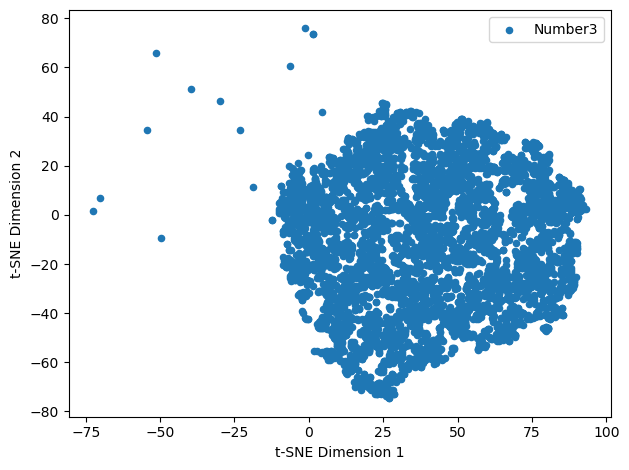

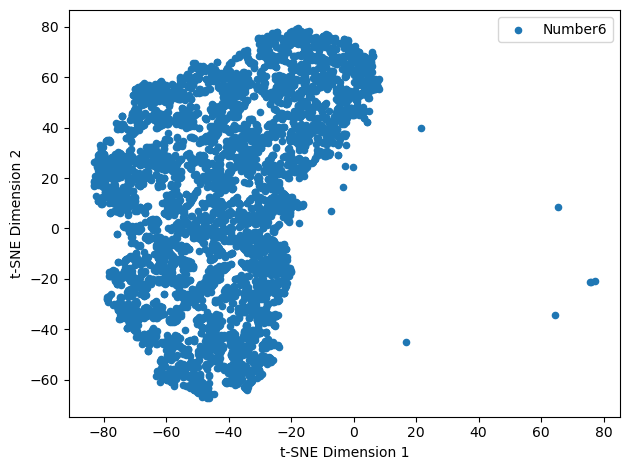

In [27]:
def visualize(x, labels):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    label2name = {0: '3', 1: '6'}
    mnist_tsne = tsne.fit_transform(x)
    for label in np.unique(labels):
        indices = labels == label
        plt.scatter(mnist_tsne[indices,0], mnist_tsne[indices,1], cmap='coolwarm', s=20, label=f'Number{label2name[label]}')
        plt. xlabel ("t-SNE Dimension 1")
        plt. ylabel ("t-SNE Dimension 2")
        plt.legend()
        plt.tight_layout()
        plt.show()
visualize(x_train, y_train)

In [8]:
# Define quantum feature mapping and building quantum kernel
dev = qml.device('default.qubit', wires=n_qubit)
@qml.qnode(dev)
def kernel(x1,x2,n_qubit):
    projector = np.zeros((2**n_qubit, 2**n_qubit))
    projector[0, 0] = 1
    qml.AngleEmbedding(x1, wires=range(n_qubit),rotation="Y")
    qml.adjoint(qml.AngleEmbedding)(x2,wires=range(n_qubit),rotation="Y")
    return qml.expval(qml.Hermitian(projector, wires=range(n_qubit)))

In [17]:
# Using the quantum kernel, we construct the kernel matrix by computing the kernel values for all pairs of samples
def kernel_mat(A, B):
    return np.array([
        [kernel(a, b, 4) for b in B]
        for a in A
    ])

In [18]:
# To achieve higher classification accuracy, we build, train, and evaluate the SVM classifier with the quantum kernel matrix
svm = SVC(kernel=kernel_mat)
svm.fit(x_train,y_train)
pred = svm.predict(x_test)
print (" Accuracy :", accuracy_score (y_test , pred ))

 Accuracy : 0.8
